Phase 2 - Data Preprocessing

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'DejaVu Sans'

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    PowerTransformer,
    QuantileTransformer,
    Normalizer,
    LabelEncoder
)
from sklearn.feature_selection import (
    SelectKBest,
    f_regression,
    mutual_info_regression,
    VarianceThreshold
)
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error
from pathlib import Path
from sklearn.preprocessing import PowerTransformer, QuantileTransformer

path = Path("../data/cleaned_data")

observation_df = pd.read_csv(path / "observation.csv")
patient_df = pd.read_csv(path / "patient.csv")
station_df = pd.read_csv(path / "station.csv")

In [2]:
station_df["revision"] = pd.to_datetime(station_df["revision"], errors="coerce")
station_df["revision"] = station_df["revision"].astype("int64") // 10**9  

le = LabelEncoder()
for col in ["station", "continent", "city", "QoS"]:
    if col in station_df.columns:
        station_df[col] = station_df[col].fillna("Missing")
        station_df[col] = le.fit_transform(station_df[col].astype(str))

display(station_df.head())

,station,longitude,QoS,latitude,revision,continent,city
0,224,86.51499,2,23.19590,1529193600,4,57
1,72,-83.48216,2,42.30865,1665360000,1,32
2,513,84.87144,2,47.46657,1478390400,4,4
3,415,30.38167,2,59.80917,1662768000,6,81
4,85,2.95924,2,36.76775,1704585600,0,3


In [3]:
merged_df = pd.merge(
    observation_df,
    station_df,
    on=["latitude", "longitude"],
    how="left"
)

In [4]:
X = merged_df.drop('oximetry', axis=1)
y = merged_df['oximetry']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(17260, 27) (4315, 27)


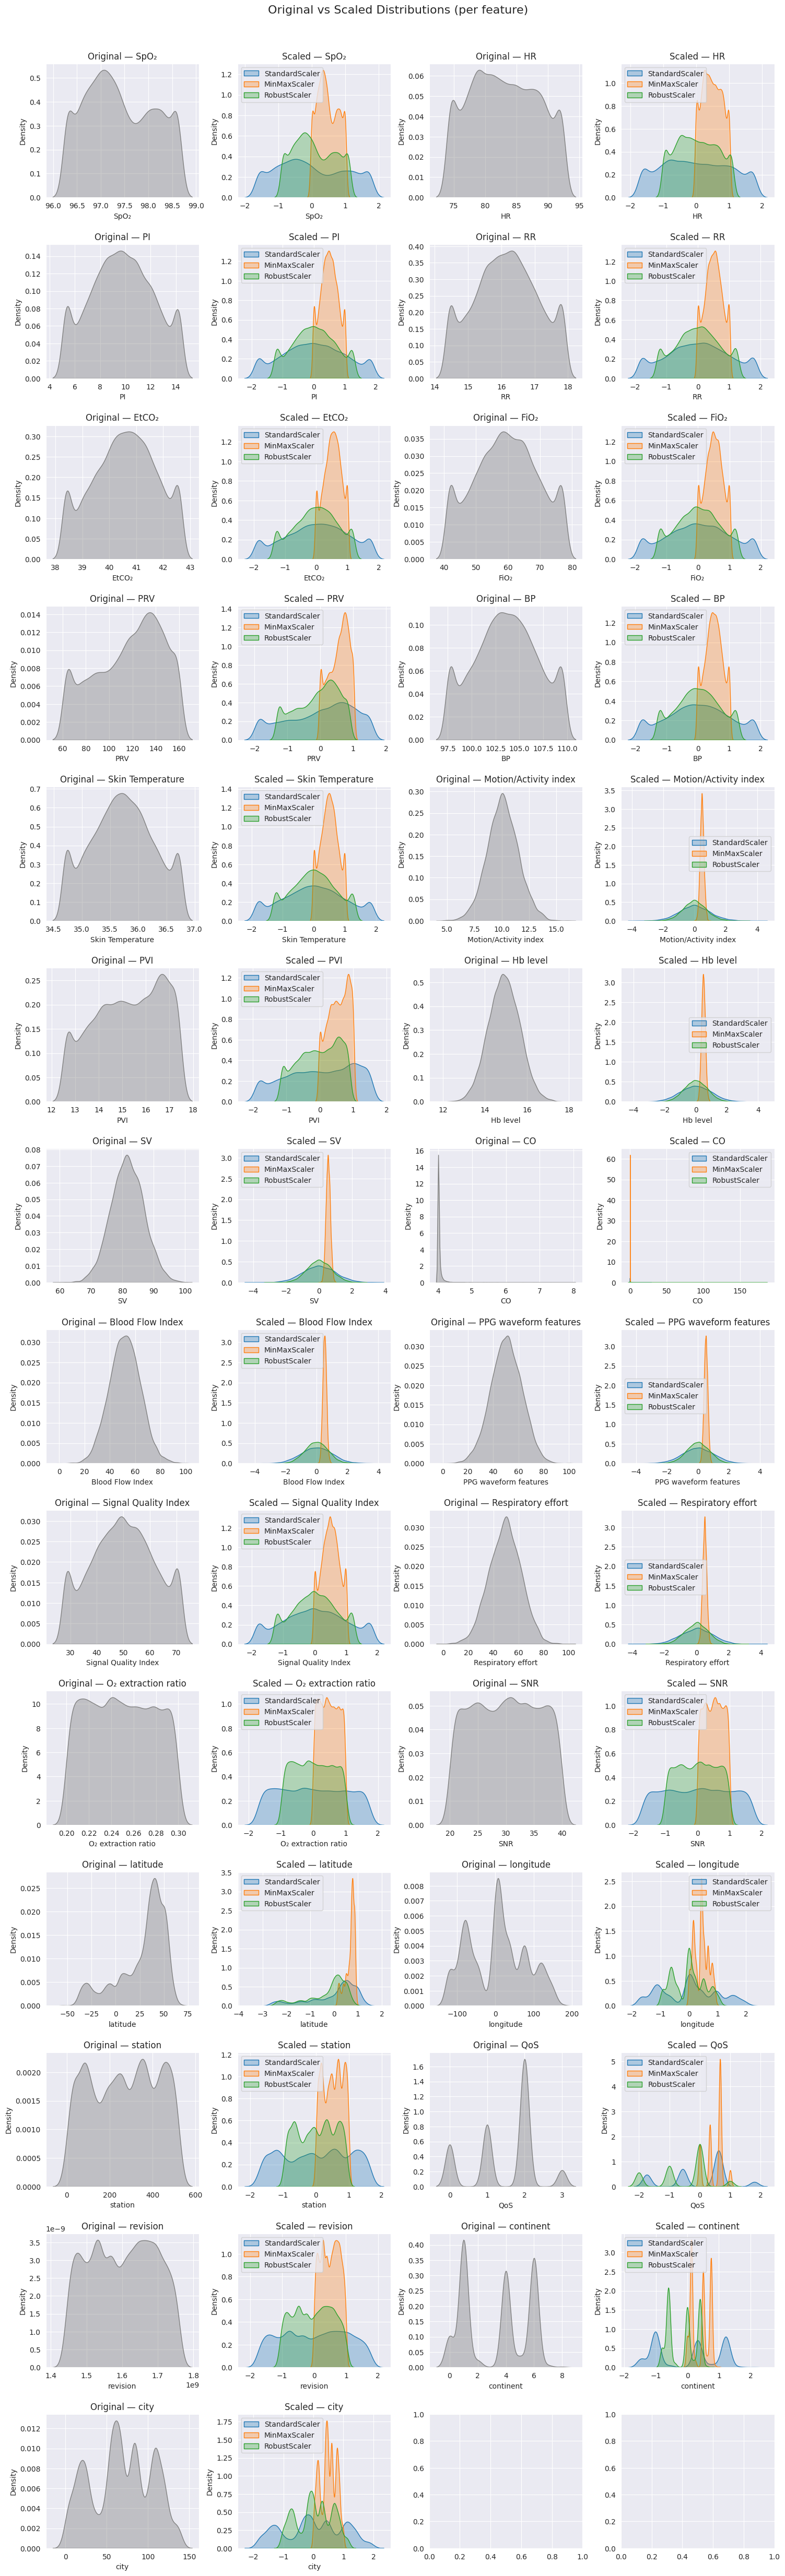

In [5]:
plt.rcParams['font.family'] = 'DejaVu Sans'


scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler(),
}

scaled_results = {"Original": X_train.copy()}
for name, scaler in scalers.items():
    scaled_results[name] = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)

features = X_train.columns
cols = 2
rows = int(np.ceil(len(features) / cols))
fig, axes = plt.subplots(rows, cols * 2, figsize=(cols * 9, rows * 4))
axes = np.atleast_2d(axes)

for i, feature in enumerate(features):
    r = i // cols
    c = (i % cols) * 2

    sns.kdeplot(scaled_results["Original"][feature], ax=axes[r, c], fill=True, color="gray", alpha=0.4)
    axes[r, c].set_title(f"Original — {feature}")

    for name, data in scaled_results.items():
        if name == "Original":
            continue
        sns.kdeplot(data[feature], ax=axes[r, c + 1], label=name, fill=True, alpha=0.3)
    axes[r, c + 1].set_title(f"Scaled — {feature}")
    axes[r, c + 1].legend()

plt.subplots_adjust(top=0.96, wspace=0.25, hspace=0.35)
plt.suptitle("Original vs Scaled Distributions (per feature)", fontsize=16)
plt.show()


,Transformer,Mean,Std,Min,Max
0,PowerTransformer,2.559674e-16,0.962250,-4.448168,4.170241
1,QuantileTransformer,4.996322e-01,0.290605,0.000000,1.000000


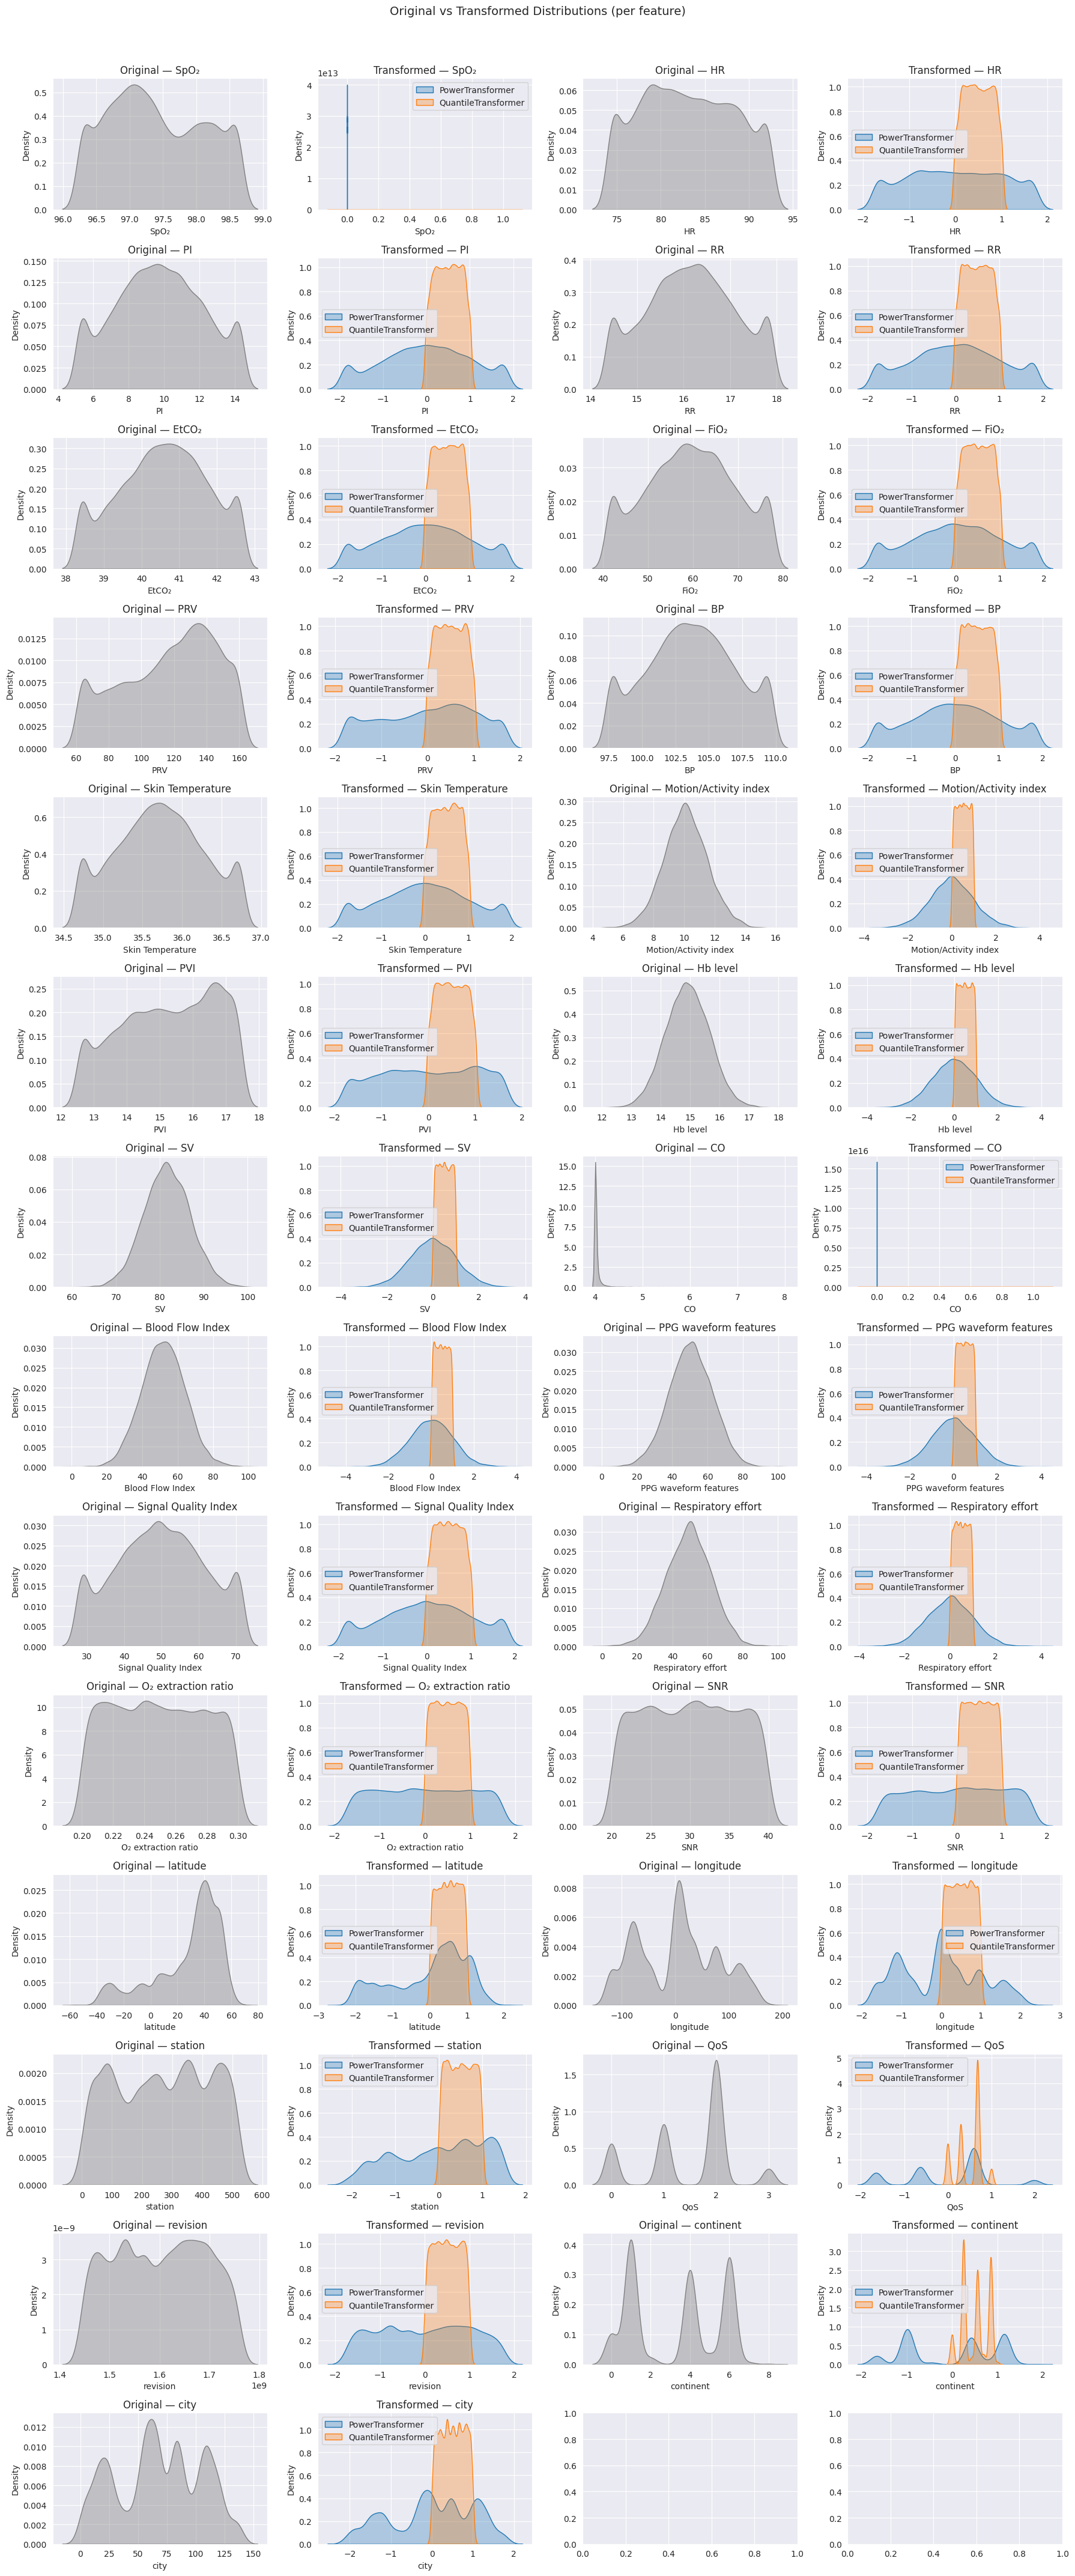

In [6]:
from sklearn.preprocessing import PowerTransformer, QuantileTransformer
plt.rcParams['font.family'] = 'DejaVu Sans'

transformers = {
    'PowerTransformer': PowerTransformer(),
    'QuantileTransformer': QuantileTransformer(n_quantiles=100, random_state=42),
}

transformed_results = {"Original": X_train.copy()}
summary = []

for name, transformer in transformers.items():
    transformer.fit(X_train)
    X_transformed = pd.DataFrame(transformer.transform(X_train), columns=X_train.columns)
    transformed_results[name] = X_transformed
    summary.append({
        "Transformer": name,
        "Mean": X_transformed.values.mean(),
        "Std": X_transformed.values.std(),
        "Min": X_transformed.values.min(),
        "Max": X_transformed.values.max()
    })

summary_df = pd.DataFrame(summary)
display(summary_df)

features = X_train.columns
n_features = len(features)
cols = 2
rows = int(np.ceil(n_features / cols))
fig, axes = plt.subplots(rows, cols * 2, figsize=(cols * 9, rows * 3))
axes = axes.reshape(rows, cols * 2)


for i, feature in enumerate(features):
    r = i // cols
    c = (i % cols) * 2
    sns.kdeplot(transformed_results["Original"][feature], ax=axes[r, c], fill=True, color="gray", alpha=0.4)
    axes[r, c].set_title(f"Original — {feature}")
    for name, data in transformed_results.items():
        if name == "Original":
            continue
        sns.kdeplot(data[feature], ax=axes[r, c + 1], label=name, fill=True, alpha=0.3)
    axes[r, c + 1].set_title(f"Transformed — {feature}")
    axes[r, c + 1].legend()


plt.tight_layout()
plt.suptitle("Original vs Transformed Distributions (per feature)", fontsize=14, y=1.02)
plt.show()



Korelacna analiza

Top 10 atribútov podľa absolútnej korelácie s oximetry:

PVI                      0.655789
PRV                      0.370316
HR                       0.263184
CO                       0.111560
EtCO₂                    0.109114
SpO₂                     0.091058
Motion/Activity index    0.028674
city                     0.023187
BP                       0.019432
PI                       0.015888
dtype: float64


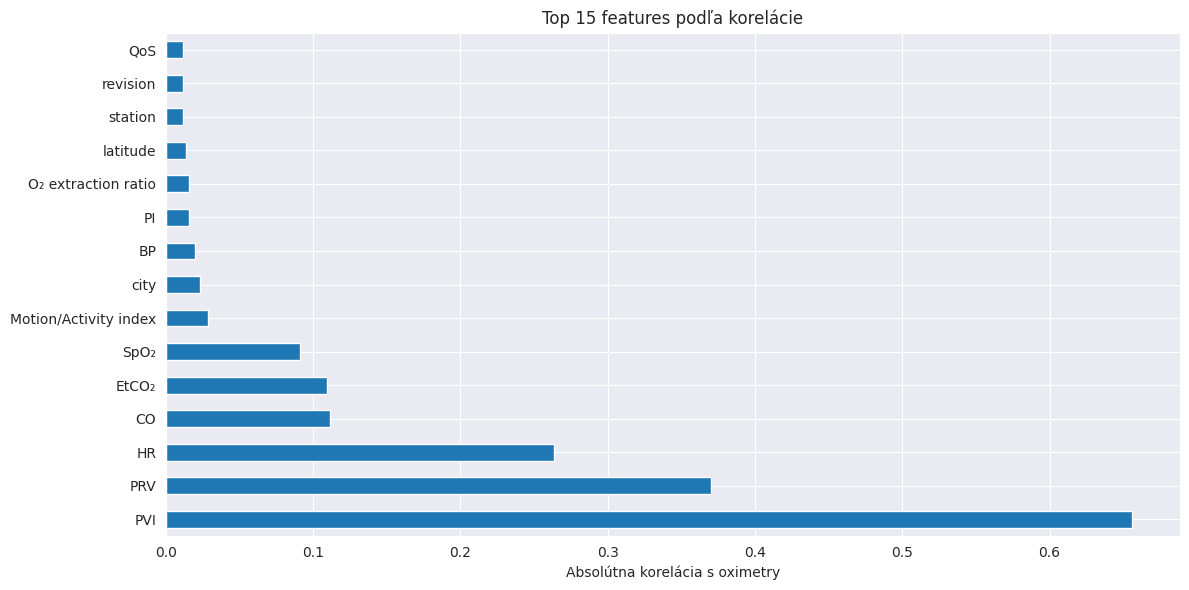

In [7]:
correlations = X_train.corrwith(y_train).abs().sort_values(ascending=False)

print("Korelacna analiza")
print("\nTop 10 atribútov podľa absolútnej korelácie s oximetry:\n")
print(correlations.head(10))

plt.figure(figsize=(12, 6))
correlations.head(15).plot(kind='barh')
plt.xlabel('Absolútna korelácia s oximetry')
plt.title('Top 15 features podľa korelácie')
plt.tight_layout()
plt.show()

correlation_ranking = correlations.to_dict()

SelectKBest (F-regression)

Top 10 atributov podla F-score:

PVI                      13022.367542
PRV                       2742.784281
HR                        1284.355849
CO                         217.491991
EtCO₂                      207.947579
SpO₂                       144.291113
Motion/Activity index       14.201122
city                         9.283756
BP                           6.519211
PI                           4.357379
dtype: float64


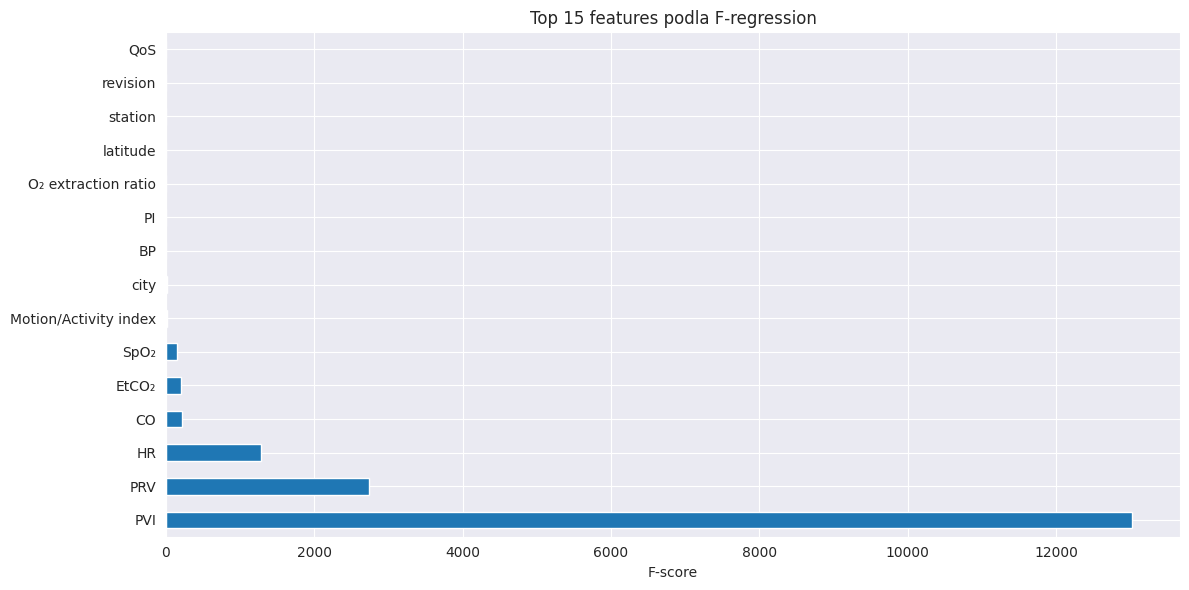

In [8]:
from sklearn.feature_selection import SelectKBest, f_regression

selector_f = SelectKBest(score_func=f_regression, k='all')
selector_f.fit(X_train, y_train)

f_scores = pd.Series(selector_f.scores_, index=X_train.columns).sort_values(ascending=False)

print("SelectKBest (F-regression)")
print("\nTop 10 atributov podla F-score:\n")
print(f_scores.head(10))

plt.figure(figsize=(12, 6))
f_scores.head(15).plot(kind='barh')
plt.xlabel('F-score')
plt.title('Top 15 features podla F-regression')
plt.tight_layout()
plt.show()

f_regression_ranking = f_scores.to_dict()

Mutual Information

Top 10 atributov podla MI score:

PVI                      0.356137
PRV                      0.235300
CO                       0.189929
HR                       0.181612
SpO₂                     0.178849
Respiratory effort       0.172651
SNR                      0.163365
PPG waveform features    0.162200
Motion/Activity index    0.161968
O₂ extraction ratio      0.160428
dtype: float64


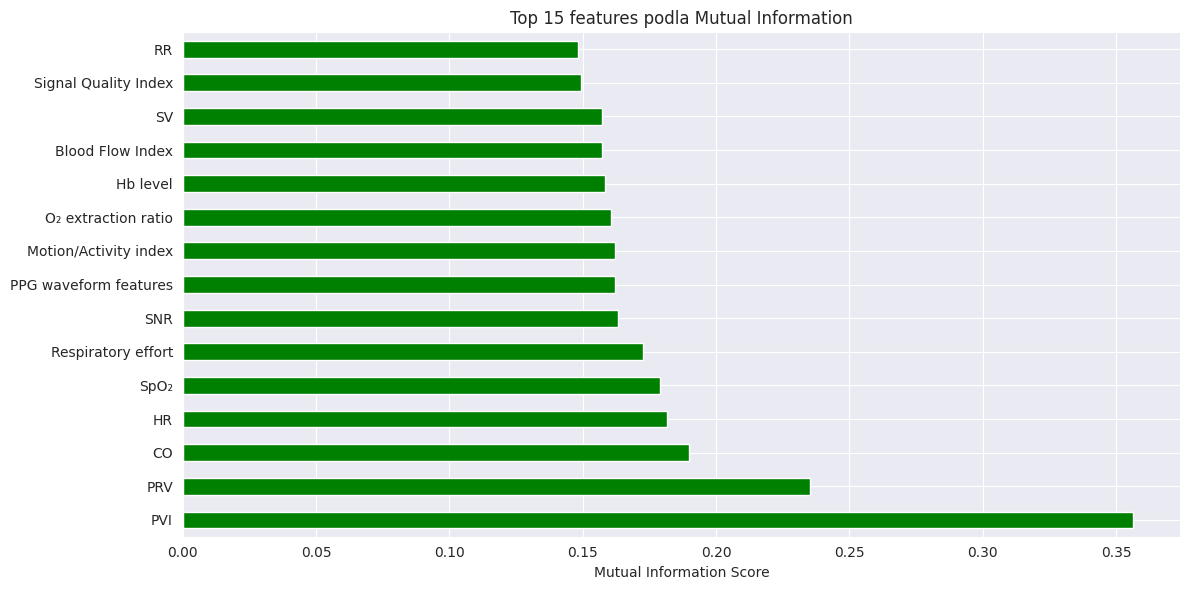

In [9]:
from sklearn.feature_selection import mutual_info_regression

mi_scores = mutual_info_regression(X_train, y_train, random_state=42)
mi_scores = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=False)

print("Mutual Information")
print("\nTop 10 atributov podla MI score:\n")
print(mi_scores.head(10))

plt.figure(figsize=(12, 6))
mi_scores.head(15).plot(kind='barh', color='green')
plt.xlabel('Mutual Information Score')
plt.title('Top 15 features podla Mutual Information')
plt.tight_layout()
plt.show()

mi_ranking = mi_scores.to_dict()

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("Random Forest Feature Importance")
print("\nTop 10 atributov podla RF importance:\n")
print(rf_importance.head(10))

plt.figure(figsize=(12, 6))
rf_importance.head(15).plot(kind='barh', color='orange')
plt.xlabel('Feature Importance')
plt.title('Top 15 features podla Random Forest')
plt.tight_layout()
plt.show()

rf_ranking = rf_importance.to_dict()

In [11]:
def normalize_scores(scores_dict):
    scores = pd.Series(scores_dict)
    return (scores - scores.min()) / (scores.max() - scores.min())

norm_corr = normalize_scores(correlation_ranking)
norm_f = normalize_scores(f_regression_ranking)
norm_mi = normalize_scores(mi_ranking)
norm_rf = normalize_scores(rf_ranking)

feature_scores = pd.DataFrame({
    'Correlation': norm_corr,
    'F-regression': norm_f,
    'Mutual_Info': norm_mi,
    'Random_Forest': norm_rf
})

feature_scores['Mean_Score'] = feature_scores.mean(axis=1)
feature_scores['Rank'] = feature_scores['Mean_Score'].rank(ascending=False)

feature_scores_sorted = feature_scores.sort_values('Mean_Score', ascending=False)

print("Finalne zoradenie atributov")
print("\nTop 15 najdôležitejších features:\n")
display(feature_scores_sorted.head(15).round(3))

Finalne zoradenie atributov

Top 15 najdôležitejších features:



,Correlation,F-regression,Mutual_Info,Random_Forest,Mean_Score,Rank
PVI,1.000,1.000,1.000,1.000,1.000,1.0
PRV,0.564,0.211,0.661,0.326,0.440,2.0
HR,0.401,0.099,0.510,0.081,0.273,3.0
CO,0.170,0.017,0.533,0.099,0.205,4.0
SpO₂,0.138,0.011,0.502,0.062,0.178,5.0
EtCO₂,0.166,0.016,0.413,0.108,0.176,6.0
Motion/Activity index,0.043,0.001,0.455,0.164,0.166,7.0
Respiratory effort,0.016,0.000,0.485,0.024,0.131,8.0
O₂ extraction ratio,0.024,0.000,0.450,0.023,0.124,9.0
SNR,0.012,0.000,0.459,0.021,0.123,10.0



✓ Výsledky uložené do 'feature_importance_rankings.csv'


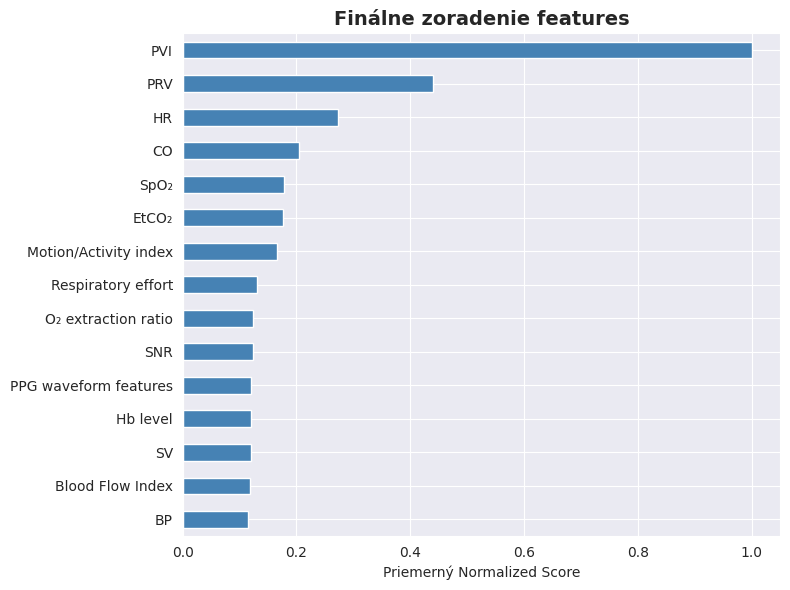

In [12]:
top_15_features = feature_scores_sorted.head(15)

fig, ax = plt.subplots(figsize=(8, 6))
top_15_features['Mean_Score'].plot(kind='barh', ax=ax, color='steelblue')

ax.set_xlabel('Priemerný Normalized Score')
ax.set_title('Finálne zoradenie features', fontsize=14, fontweight='bold')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

In [13]:
print("Analyza zhody medzi metodami")

top_k = 10
top_features = {
    'Correlation': set(feature_scores.nlargest(top_k, 'Correlation').index),
    'F-regression': set(feature_scores.nlargest(top_k, 'F-regression').index),
    'Mutual_Info': set(feature_scores.nlargest(top_k, 'Mutual_Info').index),
    'Random_Forest': set(feature_scores.nlargest(top_k, 'Random_Forest').index),
}

common_features = set.intersection(*top_features.values())
print(f"\nFeatures v top-{top_k} vsetkych metod ({len(common_features)} features):")
print(sorted(common_features))

feature_counts = {}
for feature in set.union(*top_features.values()):
    count = sum(feature in features for features in top_features.values())
    feature_counts[feature] = count

robust_features = [f for f, c in feature_counts.items() if c >= 4]
print(f"\nFeatures v top-{top_k} aspon 4 metod ({len(robust_features)} features):")
print(sorted(robust_features))

Analyza zhody medzi metodami

Features v top-10 vsetkych metod (6 features):
['CO', 'HR', 'Motion/Activity index', 'PRV', 'PVI', 'SpO₂']

Features v top-10 aspon 4 metod (6 features):
['CO', 'HR', 'Motion/Activity index', 'PRV', 'PVI', 'SpO₂']


In [14]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('select', SelectKBest(score_func=f_regression, k='all'))
])

pipeline.fit(X_test, y_test)

selector = pipeline.named_steps['select']
mask = selector.get_support()
selected_features = X.columns[mask]

coef = pipeline.named_steps['model'].coef_

coef_df = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': coef,
    'Abs_Coeff': abs(coef)
}).sort_values(by='Abs_Coeff', ascending=False)

display(coef_df.head(100))

,Feature,Coefficient,Abs_Coeff
10,PVI,0.261716,0.261716
6,PRV,0.097277,0.097277
1,HR,0.089613,0.089613
4,EtCO₂,-0.050073,0.050073
0,SpO₂,-0.020015,0.020015
26,city,0.015177,0.015177
8,Skin Temperature,0.009705,0.009705
18,O₂ extraction ratio,0.008443,0.008443
9,Motion/Activity index,-0.006120,0.006120
23,QoS,-0.005680,0.005680
